# Villanova EB manual review - drop candidates

Phase-0 audit (`labels/qc/eb_villanova_audit.csv`) flagged 30 CONTAMINATION_CONFIRMED_PLANET stars (ExoFOP says the dip is a confirmed/known planet) and 2 SUSPECT_CONFIRMED_FULL_LC stars (no eclipse even in the full light curve); the anchor TIC 233169434 (likely a delta Sct misclassified as EB) is included as panel 33. This notebook plots each candidate so the user can mark drops by hand in the final cell's CSV; no label changes happen here (ADR-0007 territory, Prof sign-off first).

In [1]:
import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
while not (root / "CLAUDE.md").exists():
    root = root.parent
sys.path.insert(0, str(root / "src" / "qc"))
from qc_common import call_with_retry
from eb_villanova_audit import index_npz_by_tic, load_corpus_cadences

logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger("eb_review")
audit = pd.read_csv(root / "labels" / "qc" / "eb_villanova_audit.csv")
mask = audit["final_verdict"].isin(["CONTAMINATION_CONFIRMED_PLANET", "SUSPECT_CONFIRMED_FULL_LC"])
targets = audit[mask | (audit["tic_id"] == 233169434)].copy()
targets = targets.sort_values(["final_verdict", "tic_id"]).reset_index(drop=True)
targets[["tic_id", "eb_period", "eclipse_snr", "final_verdict", "exofop_tfopwg_disp", "exofop_toi"]]

,tic_id,eb_period,eclipse_snr,final_verdict,exofop_tfopwg_disp,exofop_toi
0,1129033,1.360100,NaN,CONTAMINATION_CONFIRMED_PLANET,KP,398.01
1,16740101,1.481106,208.056511,CONTAMINATION_CONFIRMED_PLANET,KP,1150.01
2,25375553,2.310966,70.276344,CONTAMINATION_CONFIRMED_PLANET,KP,143.01
3,28230919,4.888042,124.220049,CONTAMINATION_CONFIRMED_PLANET,KP,1144.01
4,47911178,3.585702,86.512247,CONTAMINATION_CONFIRMED_PLANET,KP,471.01
5,55092869,4.738095,57.494077,CONTAMINATION_CONFIRMED_PLANET,KP,664.01
6,94986319,16.067553,31.726146,CONTAMINATION_CONFIRMED_PLANET,CP,421.01;421.02
7,100100827,0.941455,NaN,CONTAMINATION_CONFIRMED_PLANET,KP,185.01
8,120826158,5.179905,10.291107,CONTAMINATION_CONFIRMED_PLANET,CP;PC,4495.02;4495.01
9,120896927,4.756559,6.998808,CONTAMINATION_CONFIRMED_PLANET,CP,402.01;402.02


TOI ephemerides (period, mid-transit epoch in BTJD) for the planet-contaminated stars, so their full light curve can also be folded on the planet's period with the transit centered at phase 0.

In [2]:
toi = pd.read_csv(root / "labels" / "qc" / "toi_nasa.csv")
toi["tfopwg_disp"] = toi["tfopwg_disp"].astype(str).str.strip().str.upper()
toi = toi[toi["tfopwg_disp"].isin(["CP", "KP", "PC", "APC"])]
toi_eph = {}
for r in toi.itertuples(index=False):
    if pd.notna(r.pl_orbper) and pd.notna(r.pl_tranmid) and int(r.tid) not in toi_eph:
        toi_eph[int(r.tid)] = (float(r.pl_orbper), float(r.pl_tranmid) - 2457000.0)  # BJD --> BTJD
npz_index = index_npz_by_tic(root / "processed" / "sequences", logger)
len(toi_eph)

6351

Helpers shared by all 33 figures: the full-PDCSAP loader (per-sector MAD normalization, corpus convention; downloads hit the warm lightkurve cache) and the fold panel (raw phased points + phase-binned median curve).

In [3]:
import lightkurve as lk

def load_full_lc(tic):
    """
    Download every SPOC 2-min sector of a TIC (cache-backed) and return (times, flux).
    Quality-flagged cadences are dropped and each sector is MAD-normalized separately, matching
    the corpus convention so depths are comparable across panels.
    """
    sr = call_with_retry(lambda: lk.search_lightcurve(f"TIC {tic}", author="SPOC", cadence=120), f"search {tic}", logger)
    if len(sr) == 0:
        return np.array([]), np.array([])
    lcs = call_with_retry(lambda: sr.download_all(quality_bitmask="none"), f"download {tic}", logger)
    ts = []
    fs = []
    for lc in lcs:
        cols = {c.lower(): c for c in lc.colnames}  # MAST casing is inconsistent
        flux_col = cols.get("pdcsap_flux")
        if flux_col is None:
            continue
        t = np.asarray(lc["time"].value, dtype=np.float64)
        f = np.asarray(lc[flux_col].value, dtype=np.float64)
        q = np.asarray(lc["quality"].value) if "quality" in cols else np.zeros(len(f))
        f[q != 0] = np.nan
        keep = np.isfinite(t) & np.isfinite(f)
        t = t[keep]
        f = f[keep]
        if len(f) < 100:
            continue
        med = np.median(f)
        mad = np.median(np.abs(f - med))
        if mad <= 0:
            continue
        ts.append(t)
        fs.append((f - med) / (1.4826 * mad))
    if not ts:
        return np.array([]), np.array([])
    return np.concatenate(ts), np.concatenate(fs)

def fold_panel(ax, t, f, period, t0=None, title=""):
    """
    Phase-fold (t, f) at `period` onto one axis: raw phased points plus a binned median curve.
    With t0 the fold is centered so the event sits at phase 0; without it (Villanova gives no
    epoch) the eclipse may sit at any phase.
    """
    if len(t) == 0 or not np.isfinite(period) or period <= 0:
        ax.axis("off")
        return
    if t0 is None:
        phase = np.mod(t - t.min(), period) / period
        lo, hi = 0.0, 1.0
    else:
        phase = np.mod(t - t0 + 0.5 * period, period) / period - 0.5
        lo, hi = -0.5, 0.5
    ax.plot(phase, f, ".", markersize=1, alpha=0.2)
    bins = np.linspace(lo, hi, 201)
    idx = np.digitize(phase, bins) - 1
    centers = []
    med = []
    for b in range(200):
        sel = idx == b
        if sel.sum() >= 3:
            centers.append(0.5 * (bins[b] + bins[b + 1]))
            med.append(np.median(f[sel]))
    ax.plot(centers, med, color="crimson", linewidth=1)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("phase")

C:\Users\user1\miniconda3\envs\astro\lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## The 33 candidates

Per star: corpus fold at the Villanova `eb_period`, full-PDCSAP fold at the same period, and (planet-contaminated stars only) the full light curve folded on the TOI ephemeris with the transit centered at phase 0. A real EB shows a deep eclipse in the period folds; a planet shows only the shallow centered dip in the TOI fold.

review candidates:   0%|          | 0/33 [00:00<?, ?it/s]

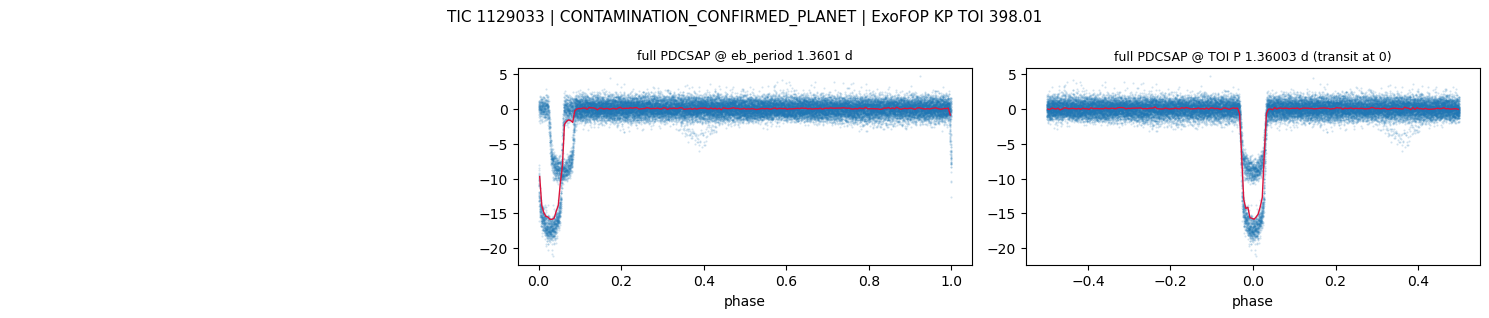

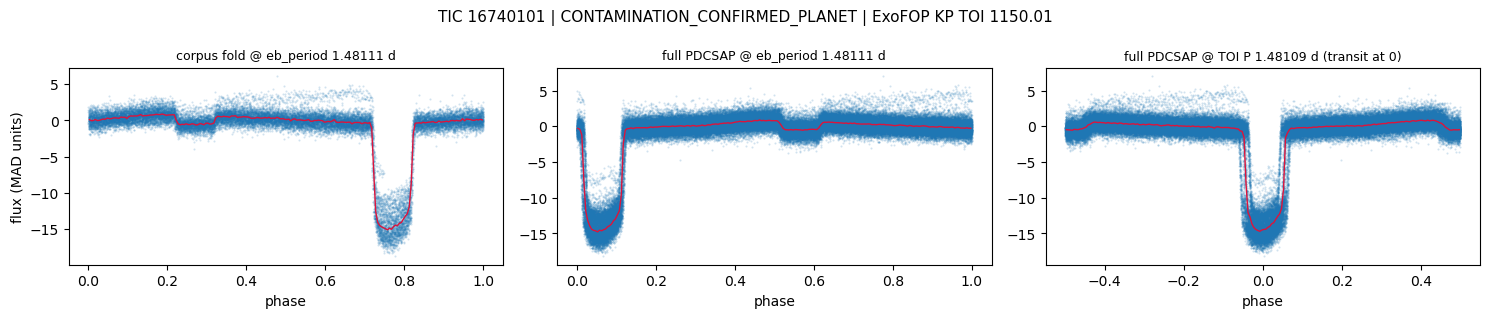

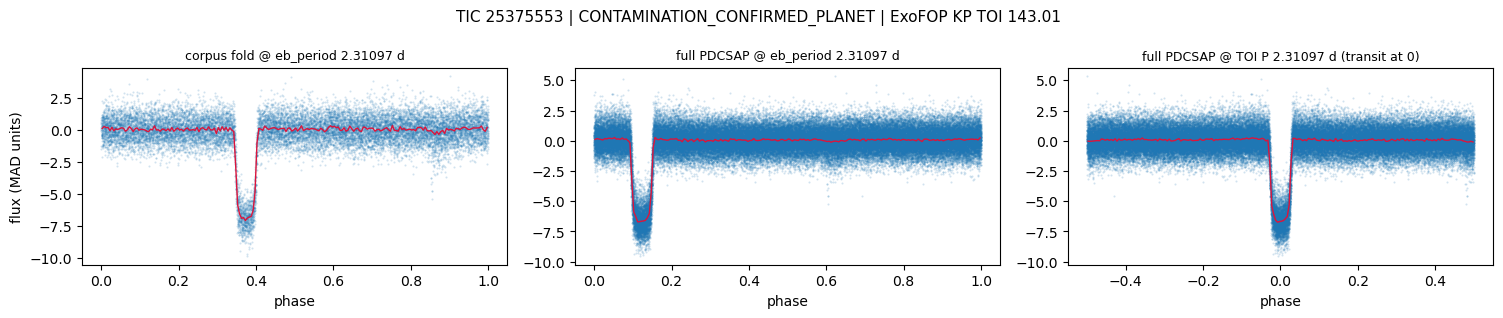

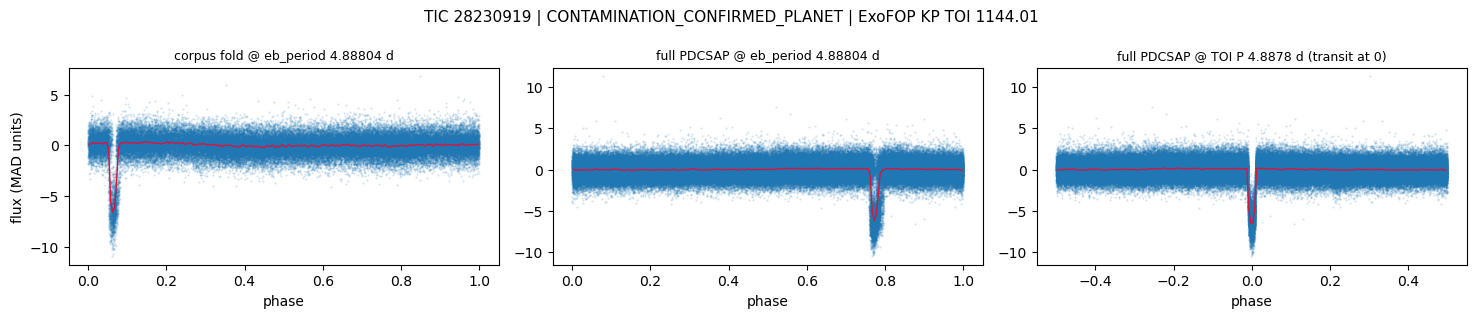

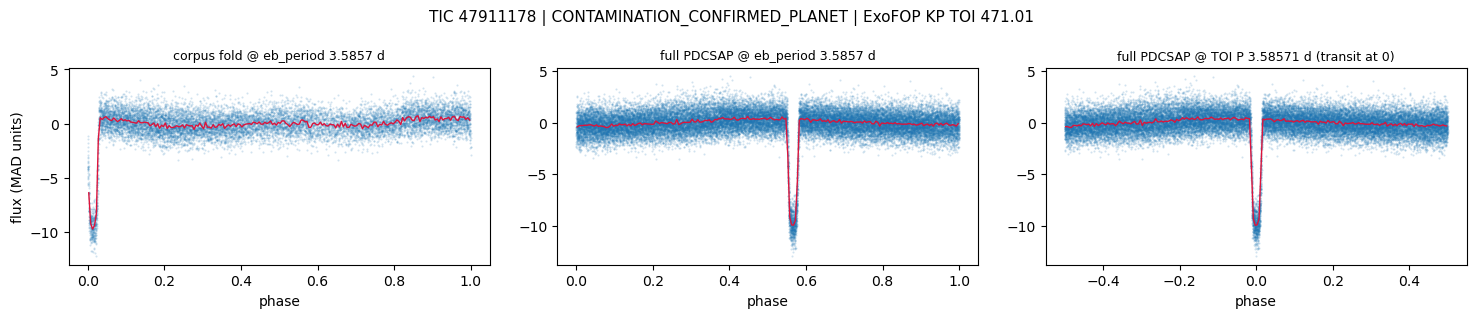

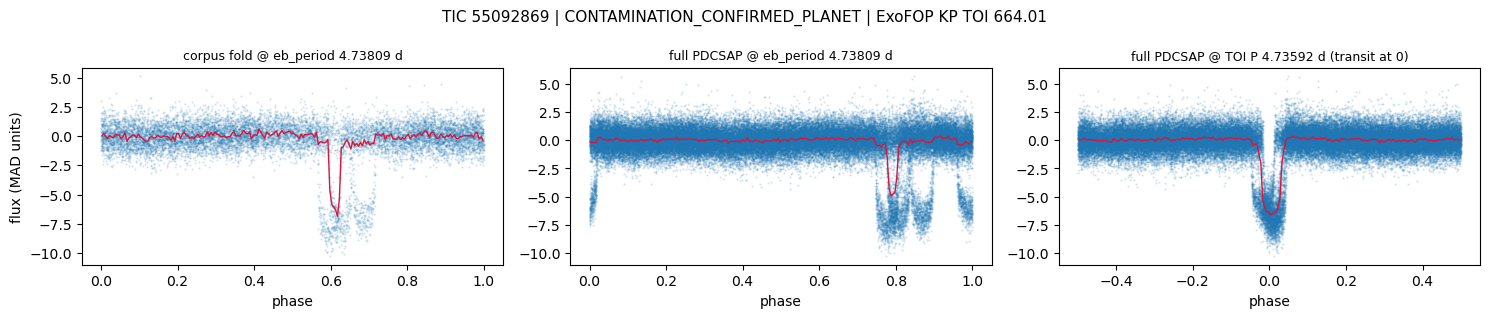

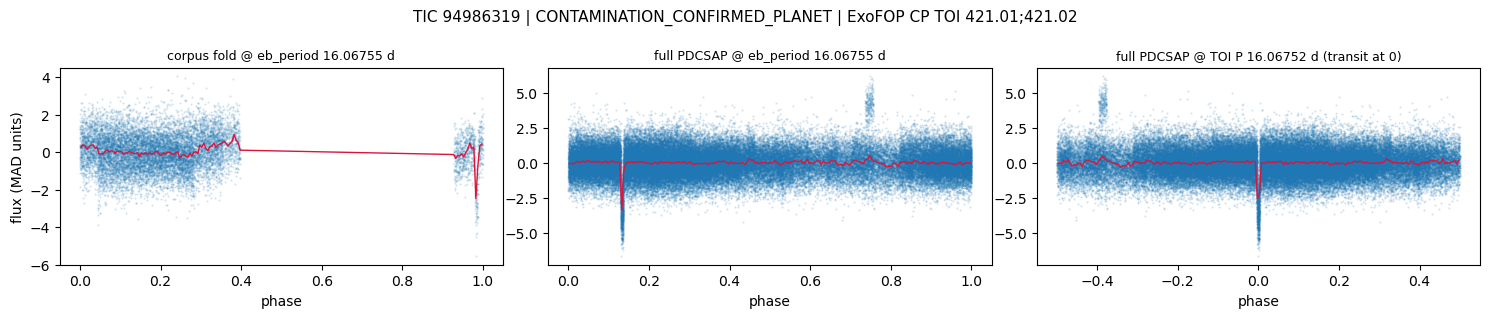

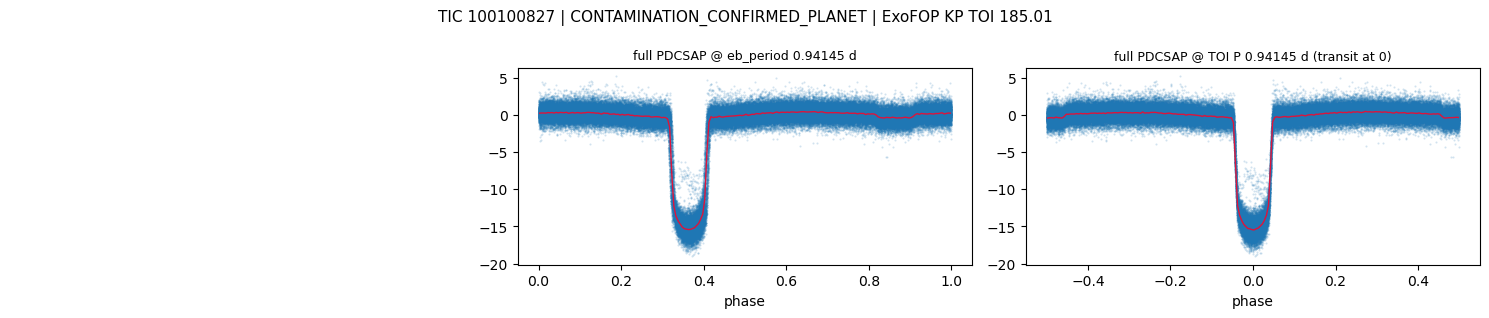

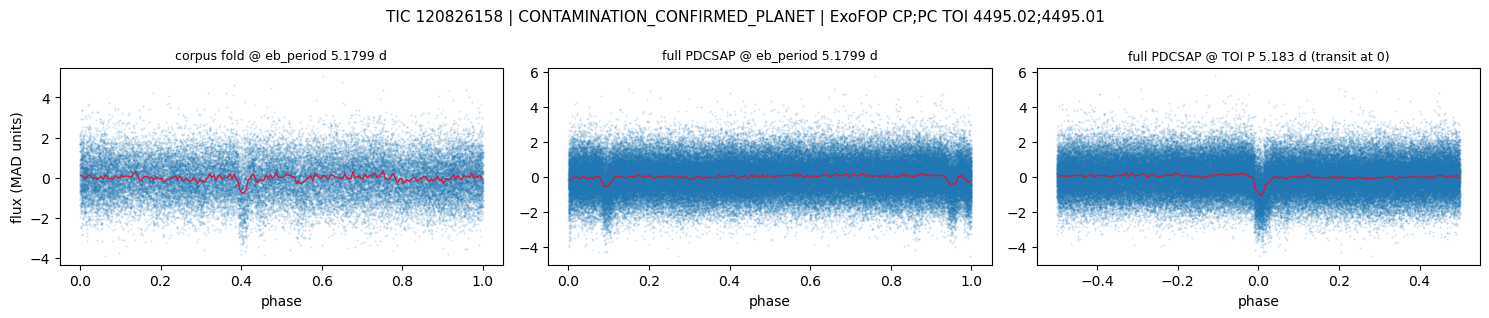

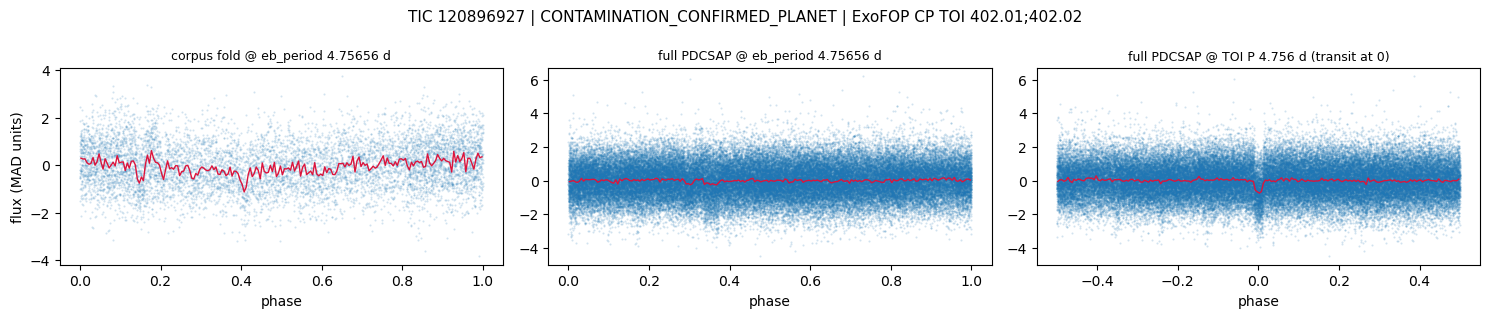

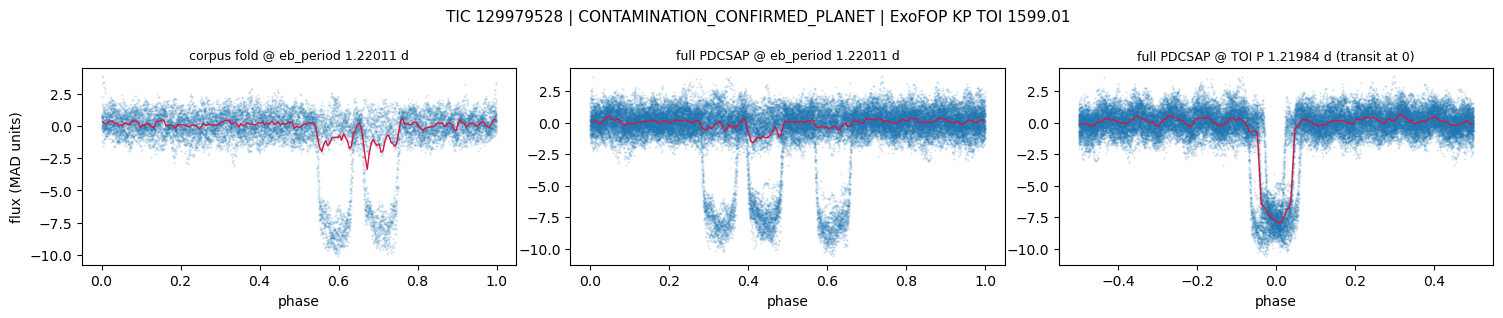

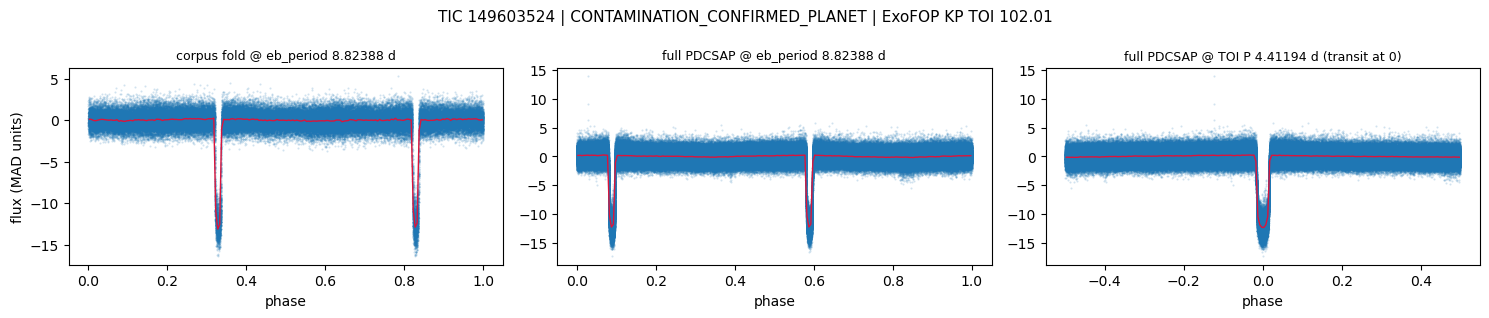

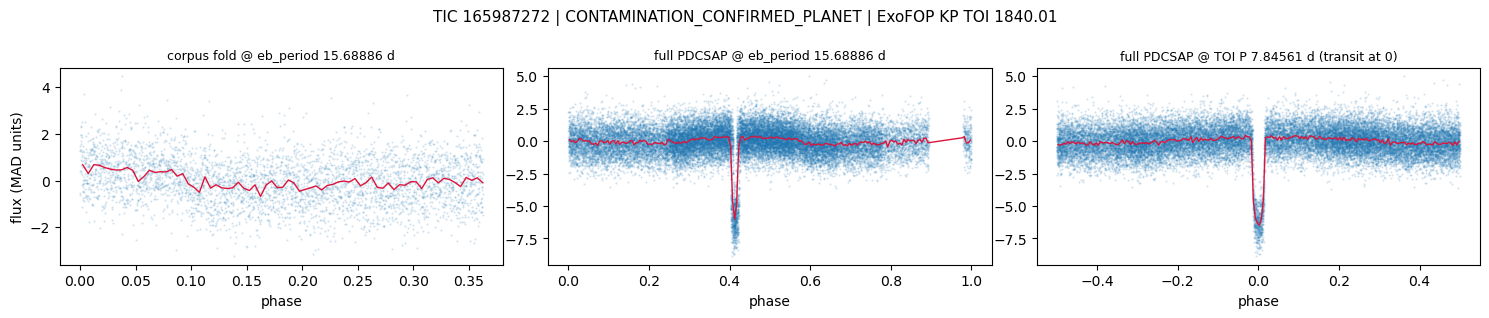

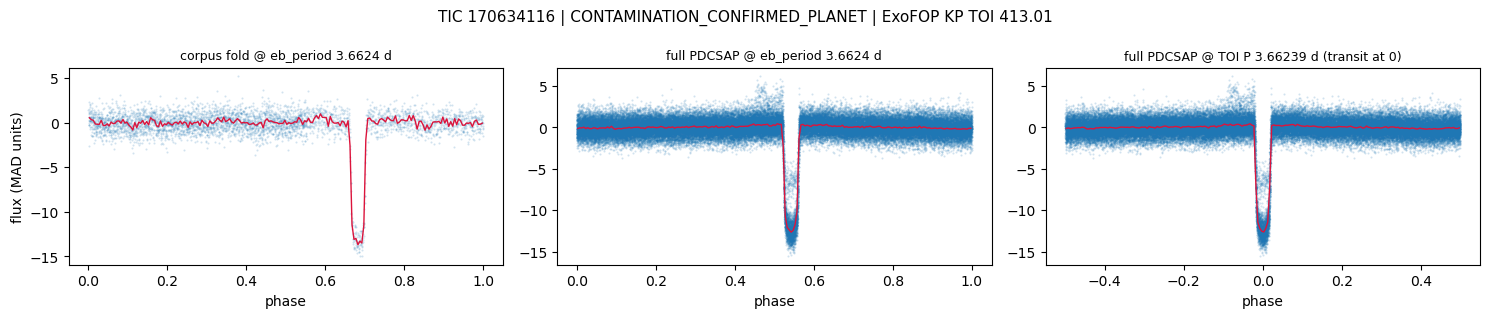

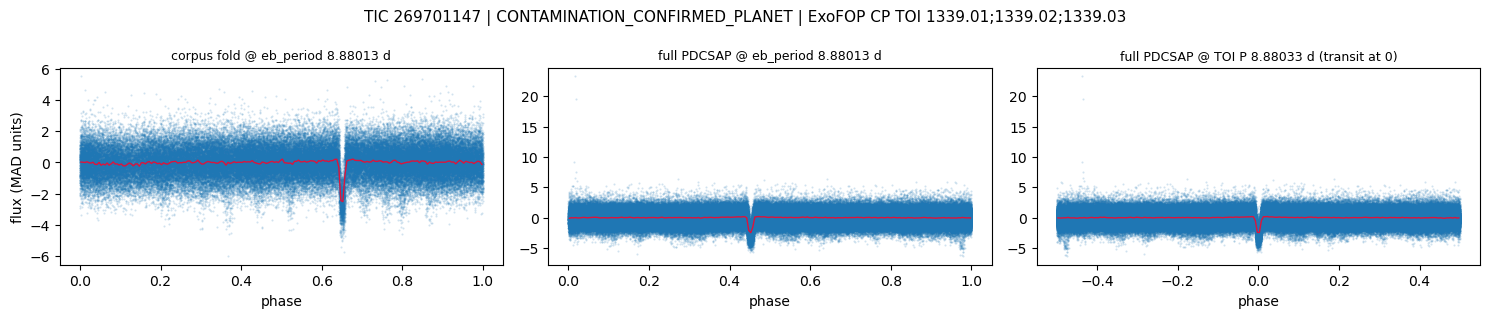

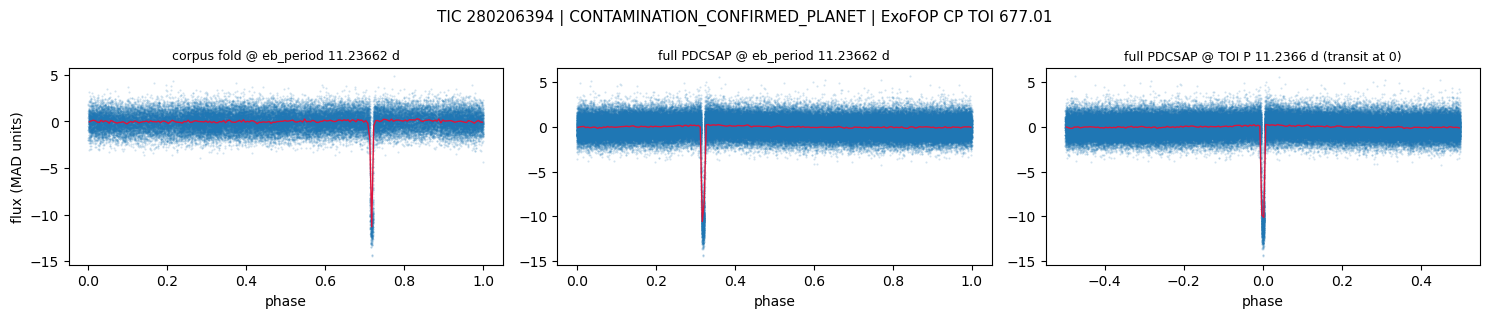

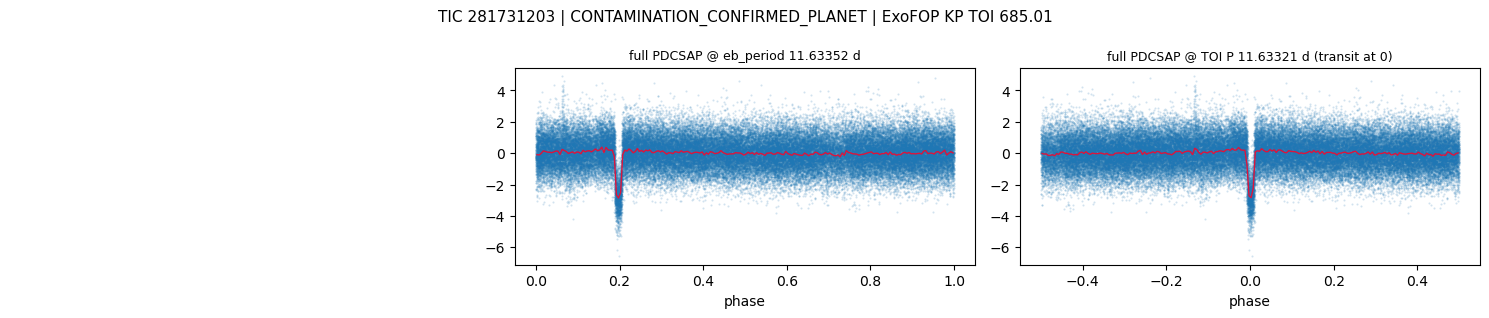

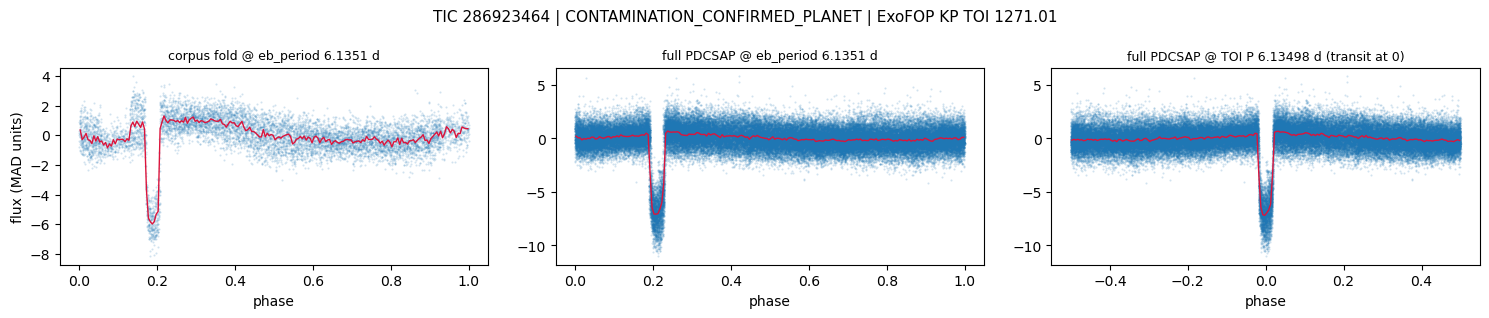

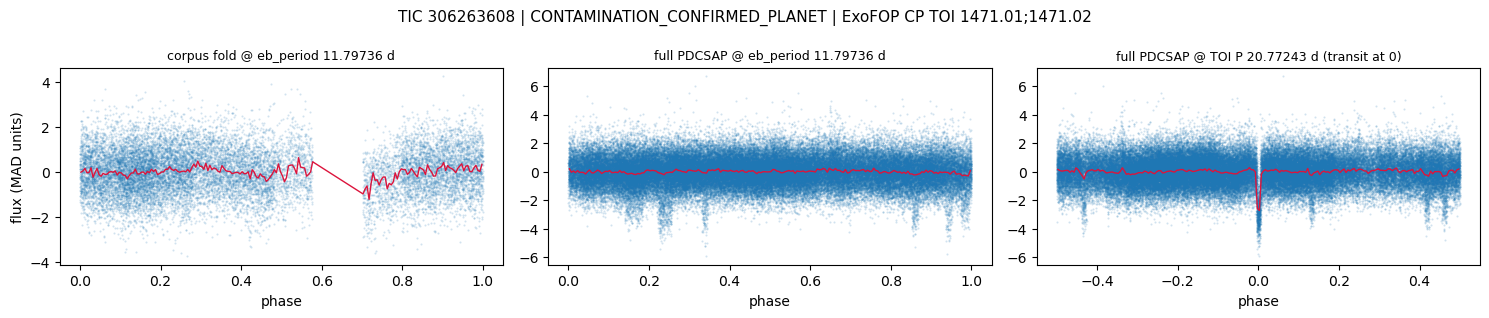

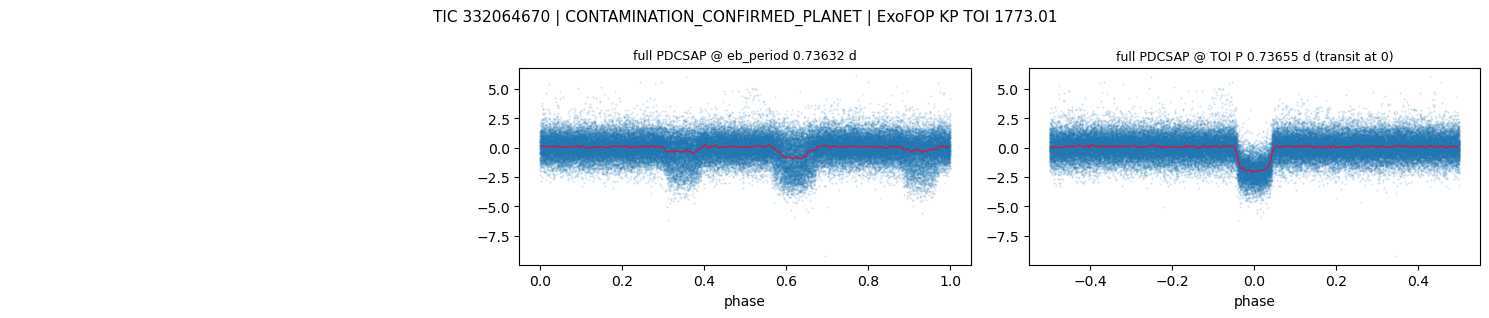

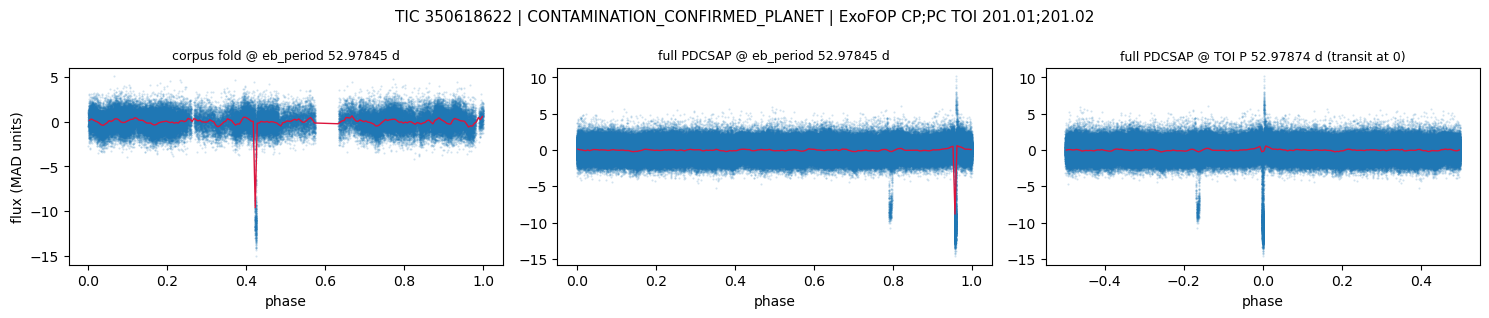

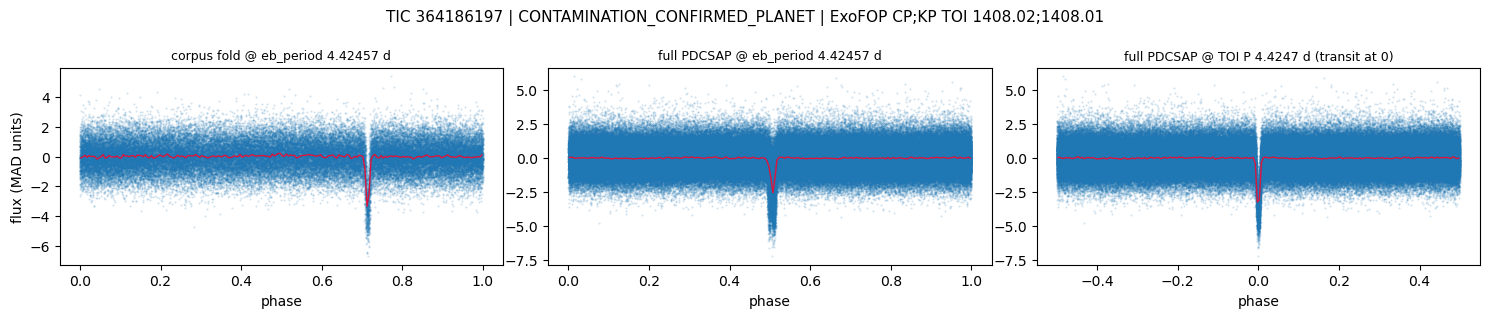

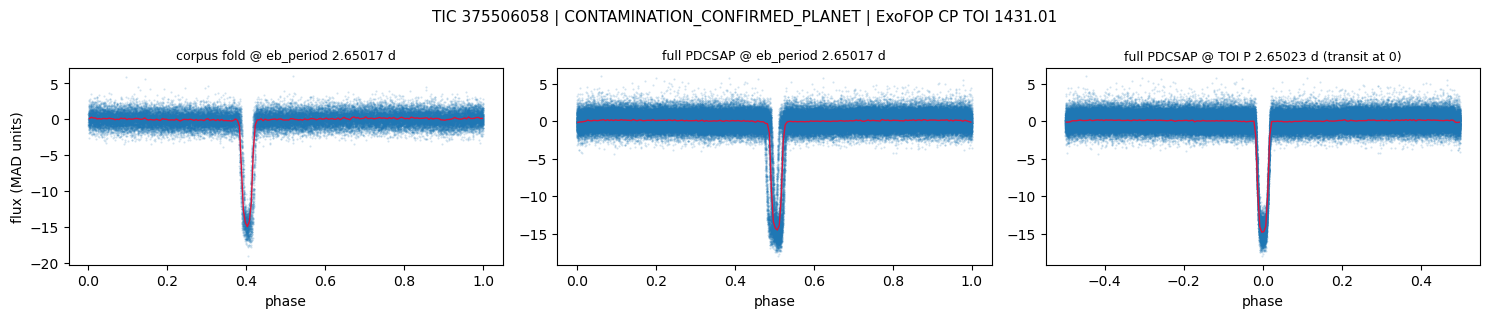

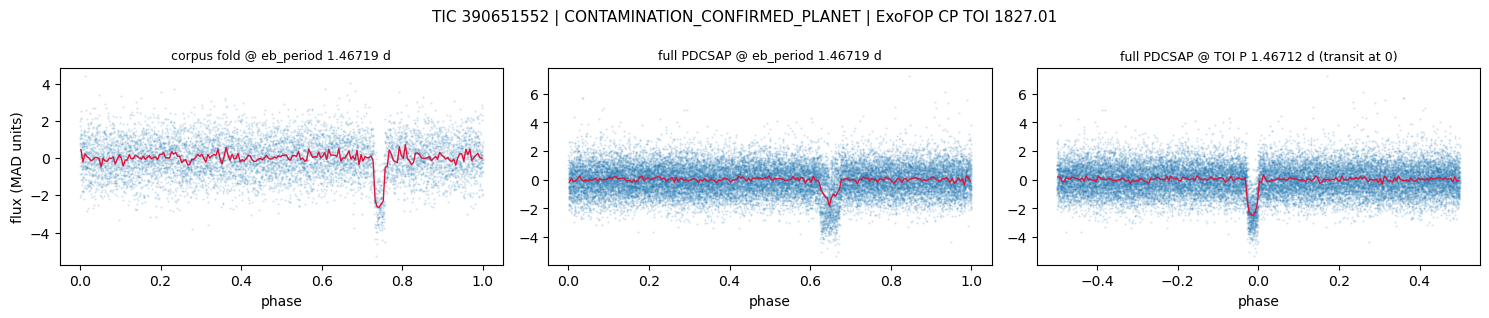

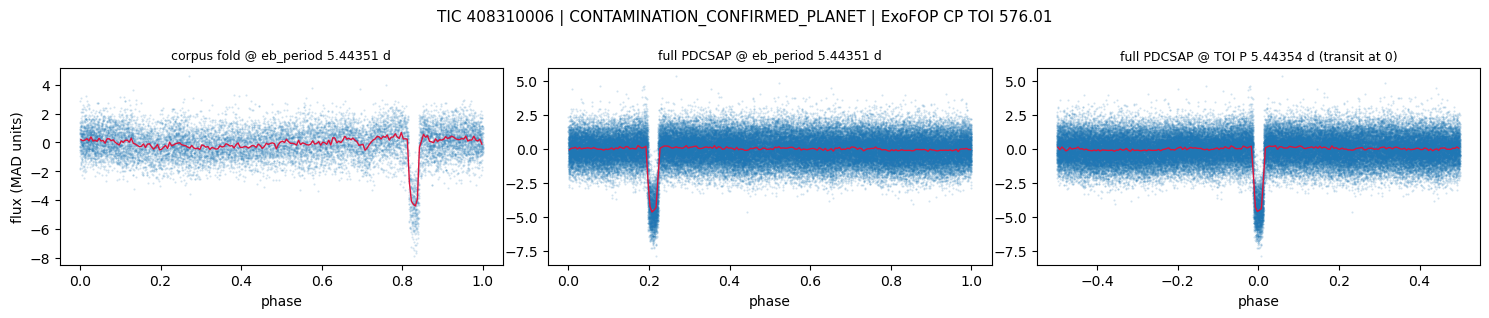

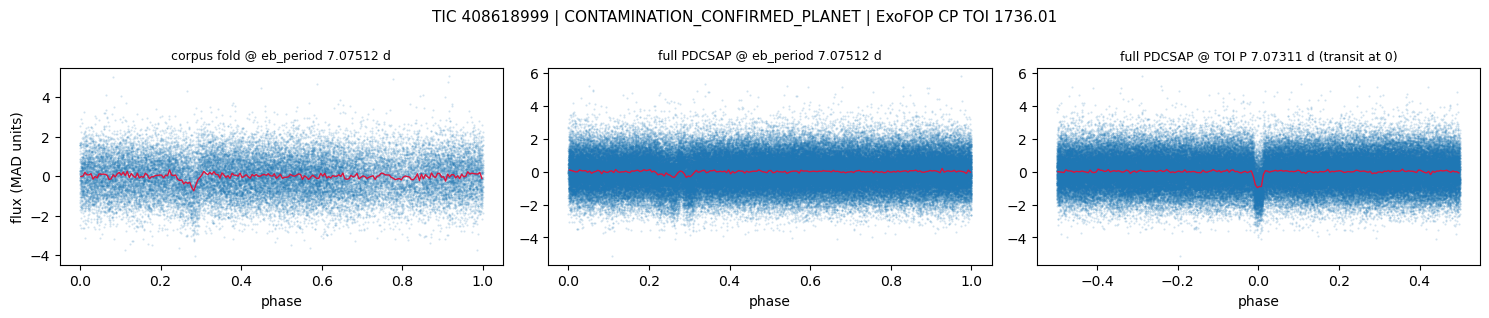

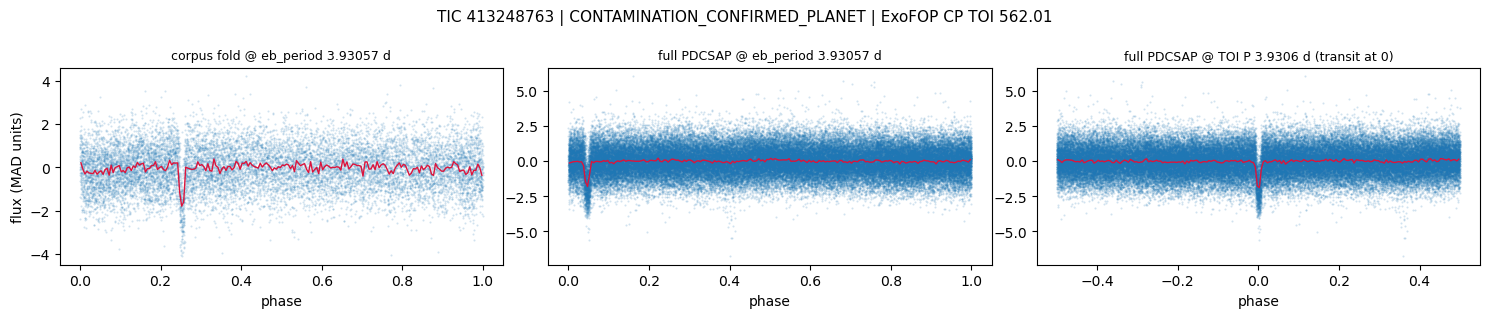

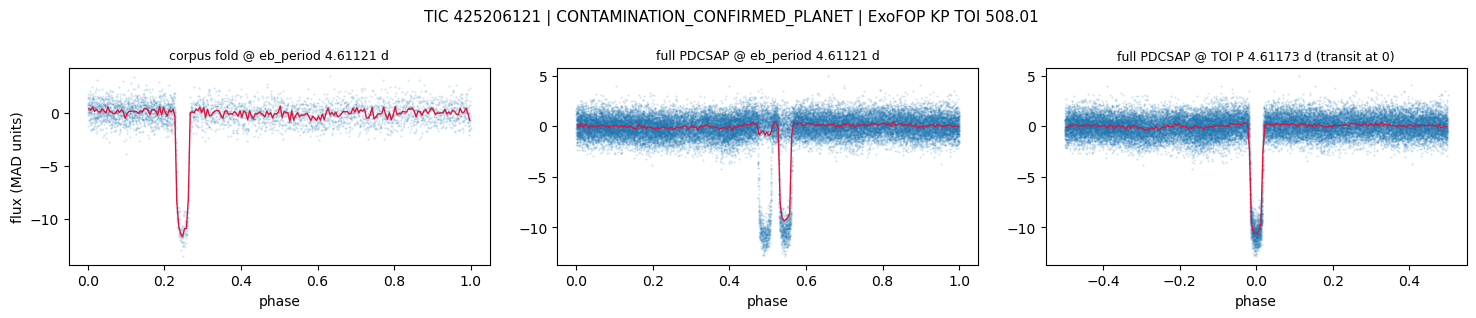

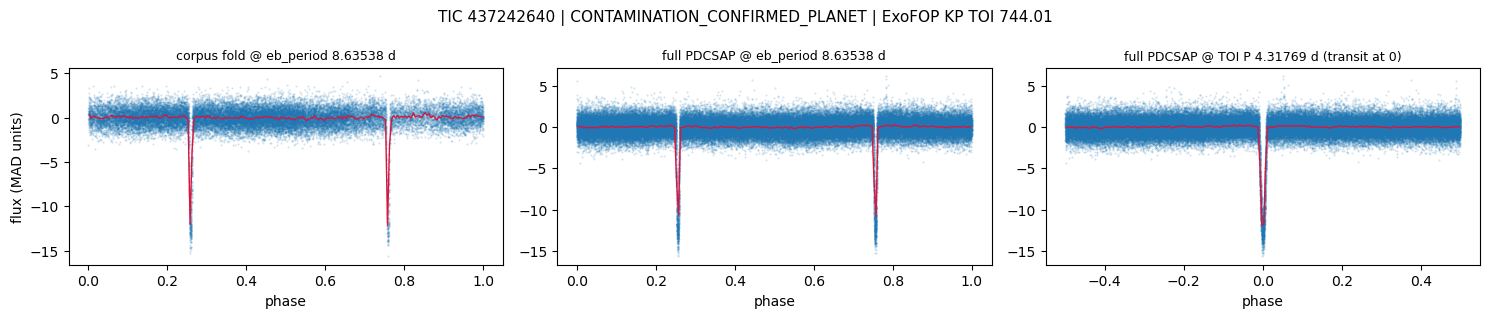

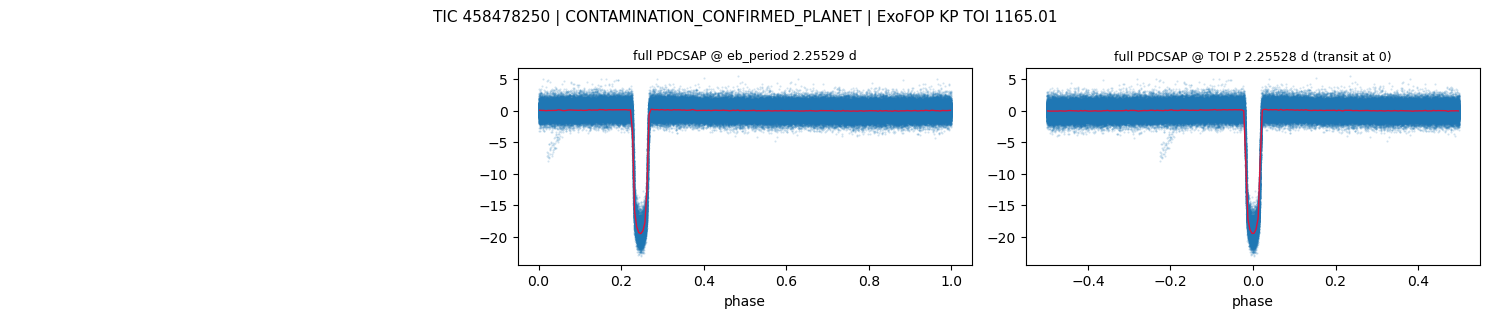

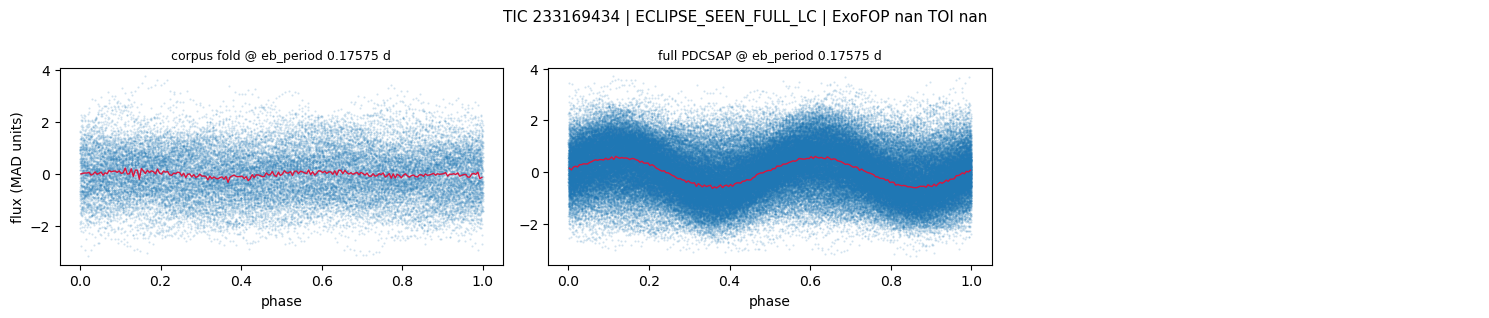

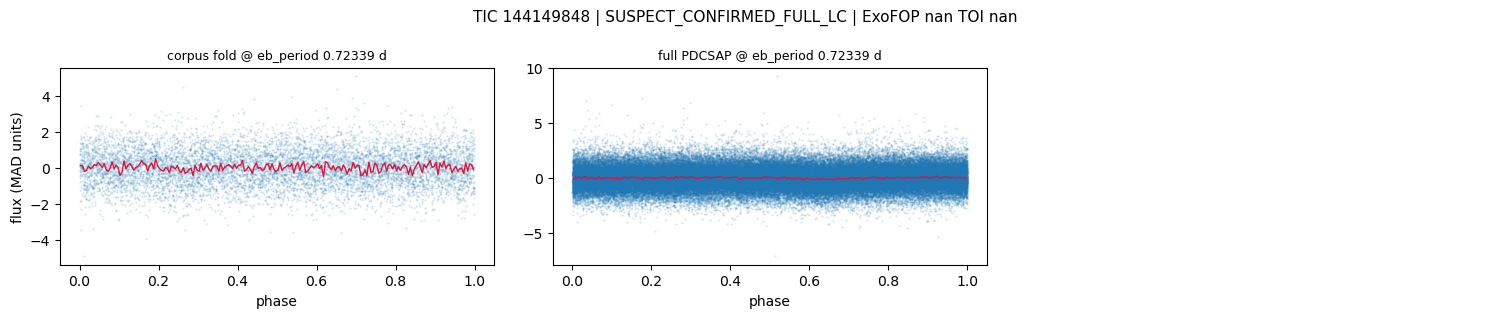

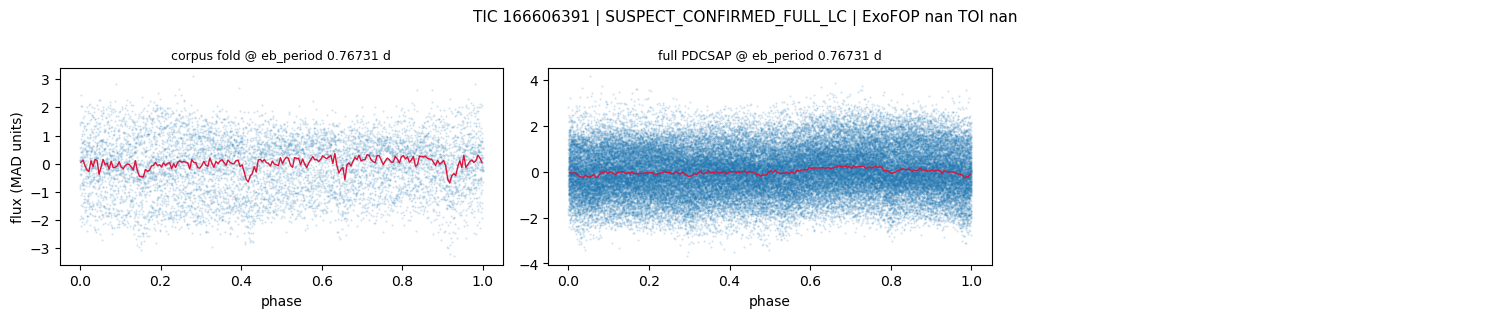

In [4]:
from tqdm.auto import tqdm

for row in tqdm(list(targets.itertuples(index=False)), desc="review candidates", total=len(targets)):
    tic = int(row.tic_id)
    paths = npz_index.get(tic, [])
    if paths:
        t_corp, f_corp = load_corpus_cadences(paths)
    else:
        t_corp, f_corp = np.array([]), np.array([])  # NO_WINDOWS star: corpus panel stays empty
    t_full, f_full = load_full_lc(tic)
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
    fold_panel(axes[0], t_corp, f_corp, row.eb_period, title=f"corpus fold @ eb_period {round(row.eb_period, 5)} d")
    fold_panel(axes[1], t_full, f_full, row.eb_period, title=f"full PDCSAP @ eb_period {round(row.eb_period, 5)} d")
    if tic in toi_eph:
        P, T0 = toi_eph[tic]
        fold_panel(axes[2], t_full, f_full, P, t0=T0, title=f"full PDCSAP @ TOI P {round(P, 5)} d (transit at 0)")
    else:
        axes[2].axis("off")
    axes[0].set_ylabel("flux (MAD units)")
    fig.suptitle(f"TIC {tic} | {row.final_verdict} | ExoFOP {row.exofop_tfopwg_disp} TOI {row.exofop_toi}", fontsize=11)
    fig.tight_layout()
    plt.show()

## Decision sheet

Fill `user_decision` per star (`drop` / `keep`) plus an optional `note` in `labels/qc/eb_manual_review.csv`. The cell never overwrites an existing sheet, so re-running the notebook preserves decisions already made.

In [5]:
review_csv = root / "labels" / "qc" / "eb_manual_review.csv"
if review_csv.exists():
    review = pd.read_csv(review_csv)
else:
    review = targets[["tic_id", "final_verdict", "eb_period", "eclipse_snr", "exofop_tfopwg_disp", "exofop_toi"]].copy()
    review["user_decision"] = ""
    review["note"] = ""
    review.to_csv(review_csv, index=False)
review

,tic_id,final_verdict,eb_period,eclipse_snr,exofop_tfopwg_disp,exofop_toi,user_decision,note
0,1129033,CONTAMINATION_CONFIRMED_PLANET,1.360100,NaN,KP,398.01,,
1,16740101,CONTAMINATION_CONFIRMED_PLANET,1.481106,208.056511,KP,1150.01,,
2,25375553,CONTAMINATION_CONFIRMED_PLANET,2.310966,70.276344,KP,143.01,,
3,28230919,CONTAMINATION_CONFIRMED_PLANET,4.888042,124.220049,KP,1144.01,,
4,47911178,CONTAMINATION_CONFIRMED_PLANET,3.585702,86.512247,KP,471.01,,
5,55092869,CONTAMINATION_CONFIRMED_PLANET,4.738095,57.494077,KP,664.01,,
6,94986319,CONTAMINATION_CONFIRMED_PLANET,16.067553,31.726146,CP,421.01;421.02,,
7,100100827,CONTAMINATION_CONFIRMED_PLANET,0.941455,NaN,KP,185.01,,
8,120826158,CONTAMINATION_CONFIRMED_PLANET,5.179905,10.291107,CP;PC,4495.02;4495.01,,
9,120896927,CONTAMINATION_CONFIRMED_PLANET,4.756559,6.998808,CP,402.01;402.02,,
